## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import pickle



## **Load Data**

In [2]:
df = pd.read_csv('final_stress_dataset_multiclass.csv')

In [3]:
df.info()

print("\nMissing values:\n", df.isnull().sum())
print("\nData Duplikat:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10406 entries, 0 to 10405
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Tweet         10406 non-null  object
 1   Label         10406 non-null  object
 2   text_stemmed  10371 non-null  object
dtypes: object(3)
memory usage: 244.0+ KB

Missing values:
 Tweet            0
Label            0
text_stemmed    35
dtype: int64

Data Duplikat: 0


In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [5]:
print("\nMissing values:\n", df.isnull().sum())
print("\nData Duplikat:", df.duplicated().sum())


Missing values:
 Tweet           0
Label           0
text_stemmed    0
dtype: int64

Data Duplikat: 0


In [6]:
df['Label'].unique()

array(['Berat', 'Sangat Berat', 'Tidak Stress', 'Sedang', 'Ringan'],
      dtype=object)

## **Modelling**
**Binary Classification dengan LSTM**

In [7]:
label_mapping = {
    'Tidak Stress': 0,
    'Ringan': 1,
    'Sedang': 2,
    'Berat': 3,
    'Sangat Berat': 4
}

df['Label_Encoded'] = df['Label'].map(label_mapping)

print(df[['Label', 'Label_Encoded']].head())

   Label  Label_Encoded
0  Berat              3
1  Berat              3
2  Berat              3
3  Berat              3
4  Berat              3


In [14]:
print(df.groupby('Label')['Label_Encoded'].first())

Label
Berat           0
Ringan          1
Sangat Berat    2
Sedang          3
Tidak Stress    4
Name: Label_Encoded, dtype: int64


In [15]:
# Tokenization
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_stemmed'])

X = tokenizer.texts_to_sequences(df['text_stemmed'])
X = pad_sequences(X, maxlen=max_len)

y = df['Label_Encoded'].values

In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model_1 = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_words,
        output_dim=128 # Increased output_dim
    ),

    LSTM(
        128, # Increased LSTM units
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(5, activation='softmax')
])

optimizer_1 = Adam(learning_rate=0.0001)

model_1.compile(
    optimizer=optimizer_1,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,229 (2.95 MB)

 Trainable params: 772,229 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_1 = EarlyStopping(
    monitor='val_loss',
    patience=5, # Increased patience
    restore_best_weights=True
)

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=30, # Increased epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_1],
    verbose=1
)

Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 58s 260ms/step - accuracy: 0.2996 - loss: 1.7404 - val_accuracy: 0.3428 - val_loss: 1.6785
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 82s 259ms/step - accuracy: 0.3528 - loss: 1.6071 - val_accuracy: 0.3669 - val_loss: 1.5113
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 81s 256ms/step - accuracy: 0.3740 - loss: 1.4816 - val_accuracy: 0.3849 - val_loss: 1.4290
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 54s 259ms/step - accuracy: 0.4140 - loss: 1.4014 - val_accuracy: 0.4307 - val_loss: 1.3551
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 56s 269ms/step - accuracy: 0.4709 - loss: 1.3198 - val_accuracy: 0.5054 - val_loss: 1.2895
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 79s 256ms/step - accuracy: 0.5345 - loss: 1.2459 - val_accuracy: 0.5235 - val_loss: 1.2401
Epoch 7/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 82s 255ms/step - accuracy: 0.5773 - loss: 1.1849 - val_accuracy: 0.5825 - val_loss: 1.1910
Epoch 8/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 53s 255ms/step - accuracy: 0.6300 - loss: 1

In [19]:
# Evaluasi
loss, accuracy = model_1.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {accuracy*100:.2f}%')

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6424 - loss: 1.0259

Test Accuracy: 64.24%


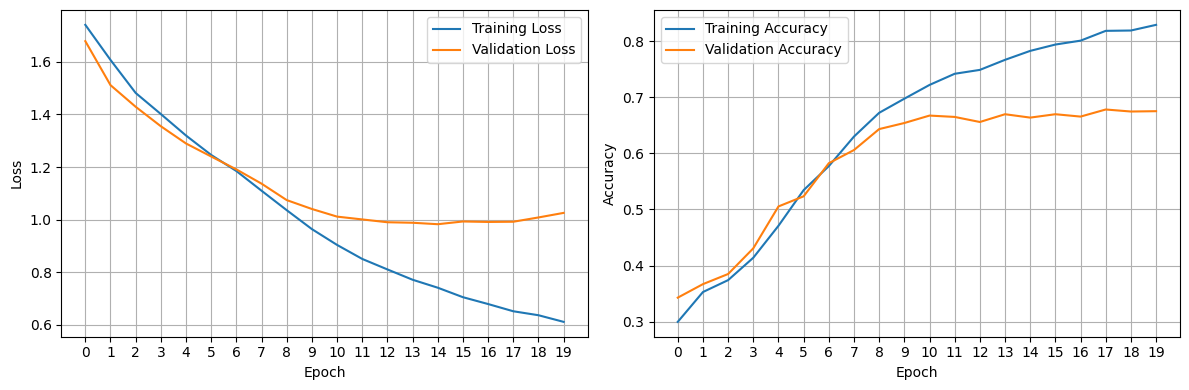

In [21]:
import matplotlib.pyplot as plt

# Epoch integer
epochs = range(len(history_1.history['loss']))

# Membuat plot horizontal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss
ax[0].plot(epochs, history_1.history['loss'], label='Training Loss')
ax[0].plot(epochs, history_1.history['val_loss'], label='Validation Loss')

ax[0].set_title('')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# Hilangkan 0.5, 1.5 dst
ax[0].set_xticks(list(epochs))

ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(epochs, history_1.history['accuracy'], label='Training Accuracy')
ax[1].plot(epochs, history_1.history['val_accuracy'], label='Validation Accuracy')

ax[1].set_title('')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

# Hilangkan 0.5, 1.5 dst
ax[1].set_xticks(list(epochs))

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
              precision    recall  f1-score   support

Tidak Stress     0.7751    0.7059    0.7389       493
      Ringan     0.4512    0.5174    0.4820       402
      Sedang     0.7018    0.6700    0.6856       397
       Berat     0.6189    0.5901    0.6041       322
Sangat berat     0.6701    0.6963    0.6830       461

    accuracy                         0.6424      2075
   macro avg     0.6434    0.6359    0.6387      2075
weighted avg     0.6508    0.6424    0.6456      2075



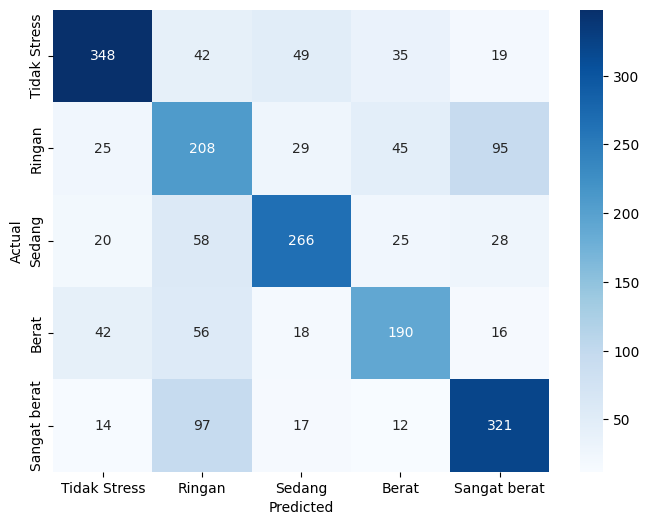

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Nama label
label_names = ['Tidak Stress', 'Ringan', 'Sedang', 'Berat', 'Sangat berat']

# Prediksi model
y_pred = model_1.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Jika y_test masih one-hot encoded, ubah ke label
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true_labels = np.argmax(y_test, axis=1)
else:
    y_true_labels = y_test

# Classification Report (4 digit)
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=label_names,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('')
plt.show()

Deep LSTM (2 Layer + Dropout)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

model_2 = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_words,
        output_dim=128 # Increased output_dim
    ),

    LSTM(
        128, # Increased LSTM units from 64 to 128
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    LSTM(
        64, # Kept at 64 units
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(5, activation='softmax')
])

optimizer_2 = Adam(learning_rate=0.0001)

model_2.compile(
    optimizer=optimizer_2,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,317 (3.13 MB)

 Trainable params: 821,317 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_2 = EarlyStopping(
    monitor='val_loss',
    patience=5, # Increased patience
    restore_best_weights=True
)

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30, # Increased epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_2],
    verbose=1
)

Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 88s 388ms/step - accuracy: 0.3113 - loss: 1.8881 - val_accuracy: 0.3512 - val_loss: 1.7962
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 82s 387ms/step - accuracy: 0.3383 - loss: 1.7135 - val_accuracy: 0.3627 - val_loss: 1.6157
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 80s 383ms/step - accuracy: 0.3579 - loss: 1.5855 - val_accuracy: 0.3777 - val_loss: 1.5309
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 80s 385ms/step - accuracy: 0.3923 - loss: 1.5098 - val_accuracy: 0.3940 - val_loss: 1.4545
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 83s 391ms/step - accuracy: 0.4248 - loss: 1.4269 - val_accuracy: 0.4524 - val_loss: 1.3968
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 83s 397ms/step - accuracy: 0.4733 - loss: 1.3539 - val_accuracy: 0.5090 - val_loss: 1.3614
Epoch 7/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 82s 395ms/step - accuracy: 0.5136 - loss: 1.3003 - val_accuracy: 0.5277 - val_loss: 1.3138
Epoch 8/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 81s 387ms/step - accuracy: 0.5597 - loss: 1

In [28]:
loss_2, acc_2 = model_2.evaluate(X_test, y_test)
print("Test Accuracy Model 2:", acc_2)

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5952 - loss: 1.2038
Test Accuracy Model 2: 0.5951807498931885


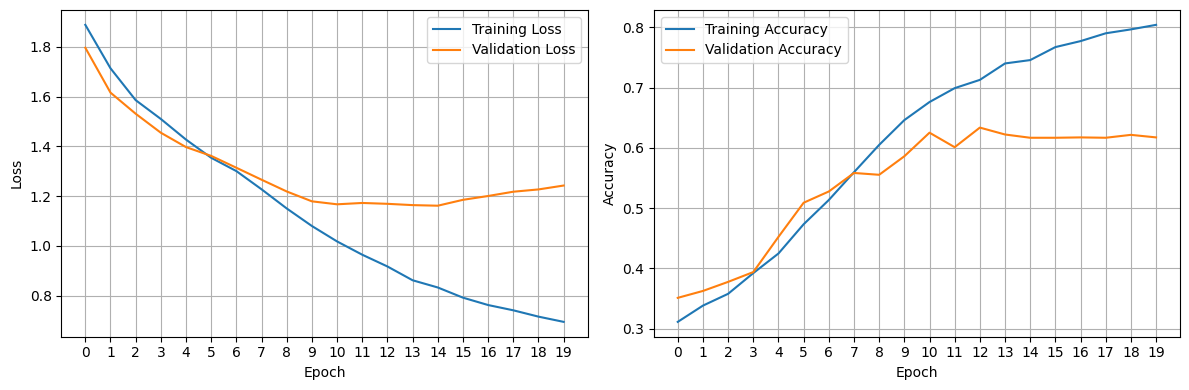

In [29]:
import matplotlib.pyplot as plt

# Epoch integer
epochs = range(len(history_2.history['loss']))

# Membuat plot horizontal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss
ax[0].plot(epochs, history_2.history['loss'], label='Training Loss')
ax[0].plot(epochs, history_2.history['val_loss'], label='Validation Loss')

ax[0].set_title('')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# Hilangkan 0.5, 1.5 dst
ax[0].set_xticks(list(epochs))

ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(epochs, history_2.history['accuracy'], label='Training Accuracy')
ax[1].plot(epochs, history_2.history['val_accuracy'], label='Validation Accuracy')

ax[1].set_title('')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

# Hilangkan 0.5, 1.5 dst
ax[1].set_xticks(list(epochs))

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step
              precision    recall  f1-score   support

Tidak Stress     0.7230    0.6937    0.7081       493
      Ringan     0.4072    0.4527    0.4287       402
      Sedang     0.6791    0.5970    0.6354       397
       Berat     0.5595    0.3944    0.4627       322
Sangat Berat     0.5993    0.7527    0.6673       461

    accuracy                         0.5952      2075
   macro avg     0.5936    0.5781    0.5804      2075
weighted avg     0.6006    0.5952    0.5929      2075



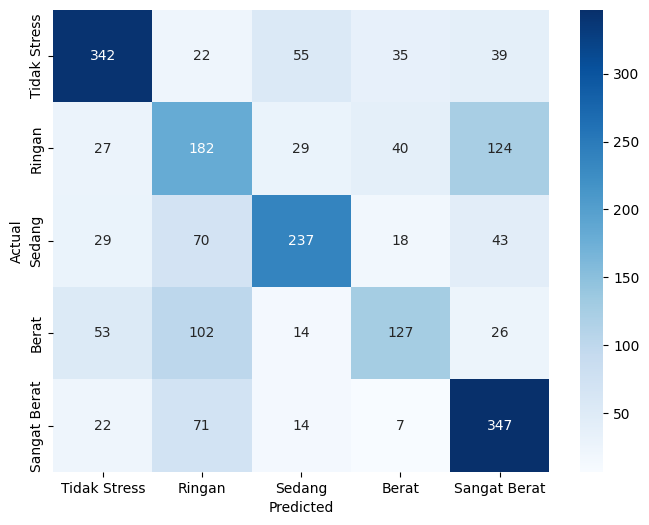

In [30]:
# Nama label
label_names = ['Tidak Stress', 'Ringan', 'Sedang', 'Berat', 'Sangat Berat']

# Prediksi probabilitas
y_pred_prob = model_2.predict(X_test)

# Ambil label multiclass
y_pred_labels = np.argmax(y_pred_prob, axis=1)

# True label
y_true_labels = y_test

# Classification Report (4 digit)
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=label_names,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Visualisasi
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("")
plt.show()

Bidirectional LSTM

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

model_3 = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim=max_words,
        output_dim=128 # Increased output_dim
    ),

    Bidirectional(
        LSTM(
            64, # Increased LSTM units
            dropout=0.2,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(0.001)
        )
    ),

    Dropout(0.5),

    Dense(5, activation='softmax')
])

optimizer_3 = Adam(learning_rate=0.0001)

model_3.compile(
    optimizer=optimizer_3,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,461 (2.82 MB)

 Trainable params: 739,461 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_3 = EarlyStopping(
    monitor='val_loss',
    patience=5, # Increased patience
    restore_best_weights=True
)

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=30, # Increased epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_3],
    verbose=1
)

Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 60s 252ms/step - accuracy: 0.2652 - loss: 1.8708 - val_accuracy: 0.3536 - val_loss: 1.7905
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 82s 250ms/step - accuracy: 0.3490 - loss: 1.7294 - val_accuracy: 0.3645 - val_loss: 1.6457
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 82s 250ms/step - accuracy: 0.3615 - loss: 1.5904 - val_accuracy: 0.3729 - val_loss: 1.5255
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 52s 252ms/step - accuracy: 0.3849 - loss: 1.4959 - val_accuracy: 0.4036 - val_loss: 1.4509
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 53s 253ms/step - accuracy: 0.4239 - loss: 1.4221 - val_accuracy: 0.4560 - val_loss: 1.3821
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 52s 252ms/step - accuracy: 0.4753 - loss: 1.3452 - val_accuracy: 0.4982 - val_loss: 1.3246
Epoch 7/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 81s 247ms/step - accuracy: 0.5068 - loss: 1.2927 - val_accuracy: 0.5036 - val_loss: 1.2948
Epoch 8/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 83s 252ms/step - accuracy: 0.5316 - loss: 1

In [33]:
loss_3, acc_3 = model_3.evaluate(X_test, y_test)
print("Test Accuracy Model 3:", acc_3)

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6381 - loss: 1.0565
Test Accuracy Model 3: 0.6380723118782043


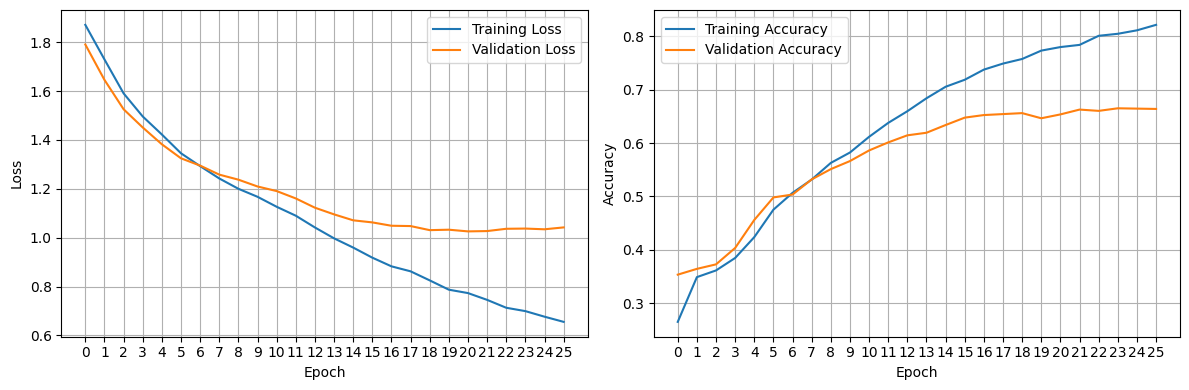

In [34]:
import matplotlib.pyplot as plt

# Epoch integer
epochs = range(len(history_3.history['loss']))

# Membuat plot horizontal
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss
ax[0].plot(epochs, history_3.history['loss'], label='Training Loss')
ax[0].plot(epochs, history_3.history['val_loss'], label='Validation Loss')

ax[0].set_title('')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

# Hilangkan 0.5, 1.5 dst
ax[0].set_xticks(list(epochs))

ax[0].legend()
ax[0].grid(True)

# Plot Accuracy
ax[1].plot(epochs, history_3.history['accuracy'], label='Training Accuracy')
ax[1].plot(epochs, history_3.history['val_accuracy'], label='Validation Accuracy')

ax[1].set_title('')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')

# Hilangkan 0.5, 1.5 dst
ax[1].set_xticks(list(epochs))

ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step
              precision    recall  f1-score   support

Tidak Stress     0.7429    0.7383    0.7406       493
      Ringan     0.4561    0.5423    0.4955       402
      Sedang     0.6856    0.6700    0.6777       397
       Berat     0.6157    0.5124    0.5593       322
Sangat Berat     0.6896    0.6746    0.6820       461

    accuracy                         0.6381      2075
   macro avg     0.6379    0.6275    0.6310      2075
weighted avg     0.6448    0.6381    0.6399      2075



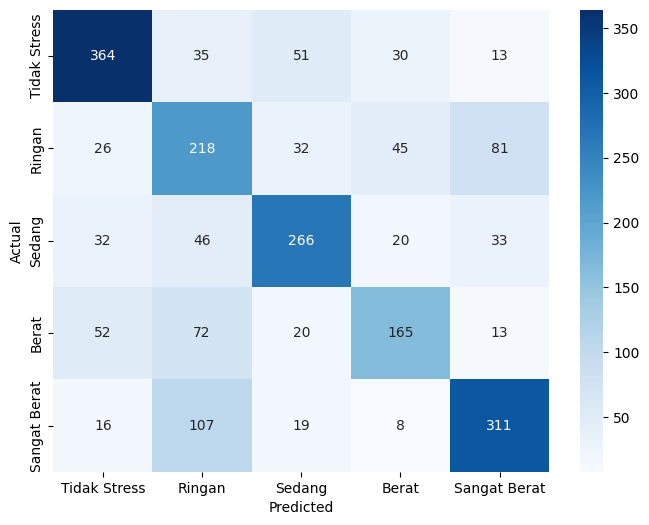

In [35]:
# Nama label
label_names = ['Tidak Stress', 'Ringan', 'Sedang', 'Berat', 'Sangat Berat']

# Prediksi
y_pred_prob = model_3.predict(X_test)

# Ambil kelas tertinggi
y_pred_labels = np.argmax(y_pred_prob, axis=1)

# True label
y_true_labels = y_test

# Classification Report (4 digit)
print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=label_names,
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Visualisasi
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("")
plt.show()

In [ ]:
model.save('../../Model/model_lstm_stress.h5')
with open('../../Model/tokenizer_stress.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
model.save('../../Model/model_lstm_stress.keras')

In [ ]:
import json

with open("../../Model/tokenizer.json", "w") as f:
    json.dump(tokenizer.word_index, f)